In [2]:
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [3]:
ticker = 'ADANIPOWER.NS'
start_date = '2023-01-01'
end_date = '2026-04-30'

data = yf.download(ticker, start_date, end_date, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [4]:
data.dropna()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-02,59.630001,60.980000,58.660000,60.599998,8688375
2023-01-03,58.950001,60.200001,58.700001,59.630001,7056560
2023-01-04,57.320000,59.200001,56.910000,58.950001,8217810
2023-01-05,57.750000,58.639999,55.400002,57.590000,9342895
2023-01-06,56.680000,58.200001,56.220001,58.139999,10998640
...,...,...,...,...,...
2026-04-23,214.179993,217.250000,212.529999,216.000000,58947381
2026-04-24,212.899994,216.869995,207.000000,215.440002,61885765
2026-04-27,218.050003,222.160004,214.600006,214.600006,57532309


In [5]:
print(type(data))

<class 'pandas.DataFrame'>


In [6]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 819 entries, 2023-01-02 to 2026-04-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   819 non-null    float64
 1   High    819 non-null    float64
 2   Low     819 non-null    float64
 3   Open    819 non-null    float64
 4   Volume  819 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 38.4 KB


Text(0.5, 1.0, 'AdaniPower Close Price')

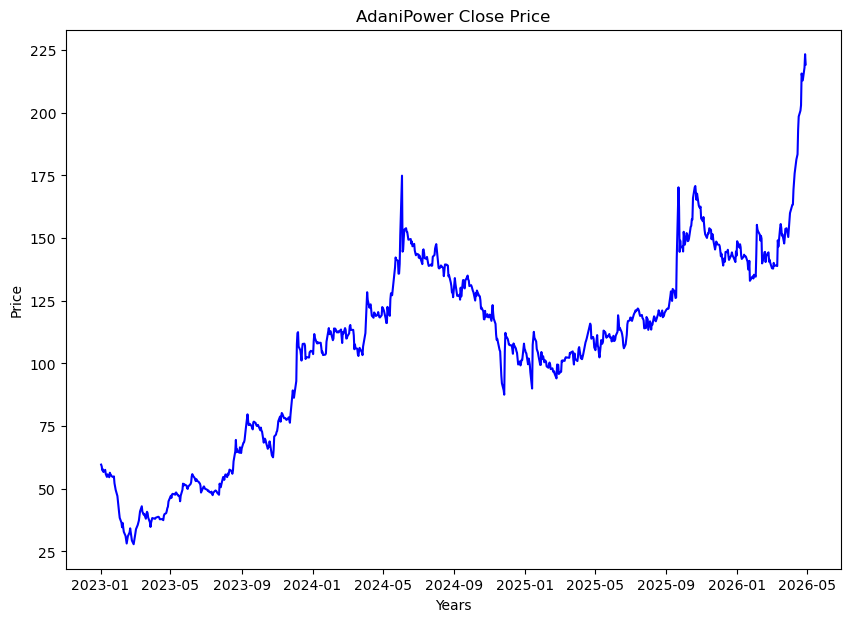

In [7]:
#plot the series 
plt.figure(figsize=(10,7))
plt.plot(data['Close'],'blue')
plt.xlabel('Years')
plt.ylabel('Price')
plt.title('AdaniPower Close Price')

From the above plot, you can see that the time series has a increaing trend. Hence it is not stationary. Let's apply the Augmented Dickey Fuller Test and verify the same statistically.

### Augmented Dickey Fuller Test

The ADF test, we test the null hypothesis that the time series is not stationary. If the p-value < 0.05, you reject the null hypothesis.

In [9]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(data['Close'])

if (results[0] < 0.05):
    print('The series is stationary as the p-value = %.2f <= 0.05' % results[1])
else:
    print('The series is not stationary as the p-value = %.2f > 0.05' % results[1])    

The series is not stationary as the p-value = 0.98 > 0.05


### Making series into stationary

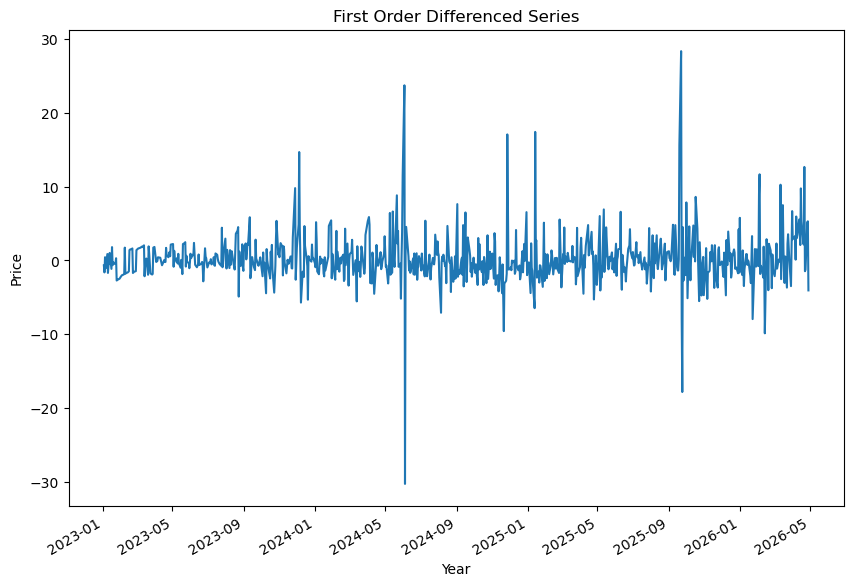

In [10]:
# Difference of the series
stationary_series = data['Close'].diff().dropna()

# Plot the difference
plt.figure(figsize=(10, 7))
stationary_series.plot()
plt.title('First Order Differenced Series')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

In [12]:
#rechecking stationarity
result = adfuller(stationary_series)

if(result[1] < 0.05):
    print('The series is stationary as the p-value = %.2f <= 0.05'
          % result[1])
else:
    print('The series is not stationary as the p-value = %.2f > 0.05'
          % result[1])

The series is stationary as the p-value = 0.00 <= 0.05


## Parameters of ARIMA(p,d,q)

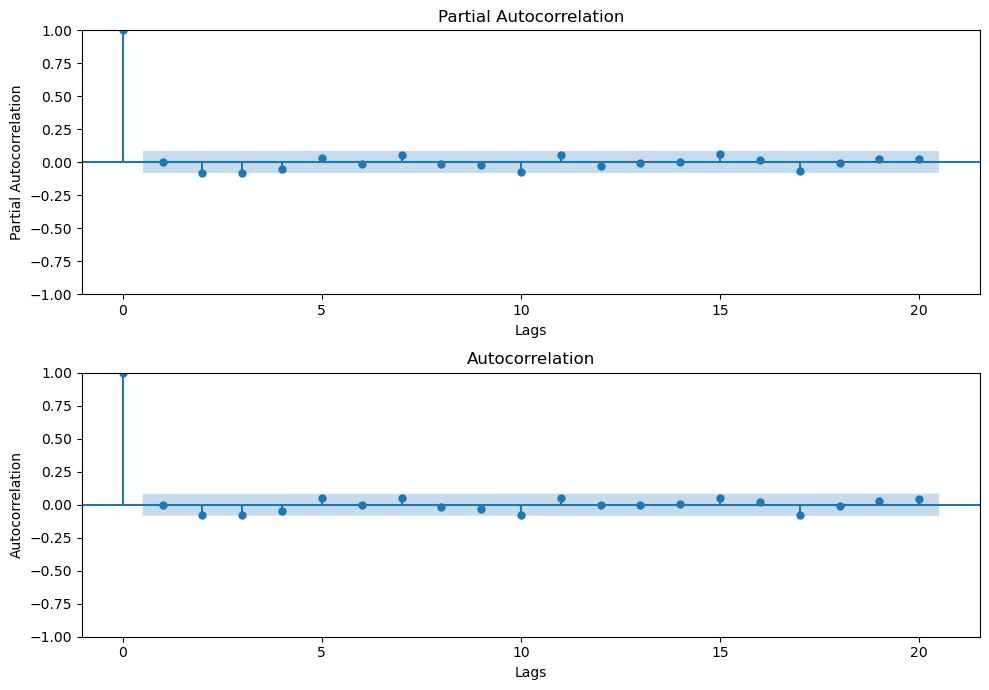

In [15]:
rolling_window = int(len(data)*0.70)

# Find the order of AR and MA
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Plot Partial Autocorrelation Function
plot_pacf(data['Close'][:rolling_window].diff().dropna(), lags=20, ax=ax1)
ax1.set_xlabel('Lags')
ax1.set_ylabel('Partial Autocorrelation')

# Plot Autocorrelation Function
plot_acf(data['Close'][:rolling_window].diff().dropna(), lags=20, ax=ax2)
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

In [17]:
# Fit ARIMA model
model = ARIMA(data['Close'][:rolling_window], order=(2, 1, 2))
model_fit_0 = model.fit()
print(model_fit_0.params.round(2))

ar.L1     1.12
ar.L2    -0.84
ma.L1    -1.13
ma.L2     0.79
sigma2    9.02
dtype: float64


In [22]:
from statsmodels.tsa.arima.model import ARIMA

def predict_price_ARIMA(train_data):
    model = ARIMA(train_data, order=(2, 1, 2))
    
    # safer fit (remove start_params unless needed)
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=1)
    
    return float(forecast.iloc[0])   # ✅ scalar output

In [23]:
# Predict the price using `predict_price_MA` function
data['predicted_price'] = data['Close'].rolling(rolling_window).apply(predict_price_ARIMA)
# Shift the predicted price by 1 period
data['predicted_price'] = data['predicted_price'].shift(1)

The Mean Absolute Error is 2.47
The Mean Squared Error is 15.59
The Root Mean Squared Error is 3.95
The Mean Absolute Percentage Error is 1.72


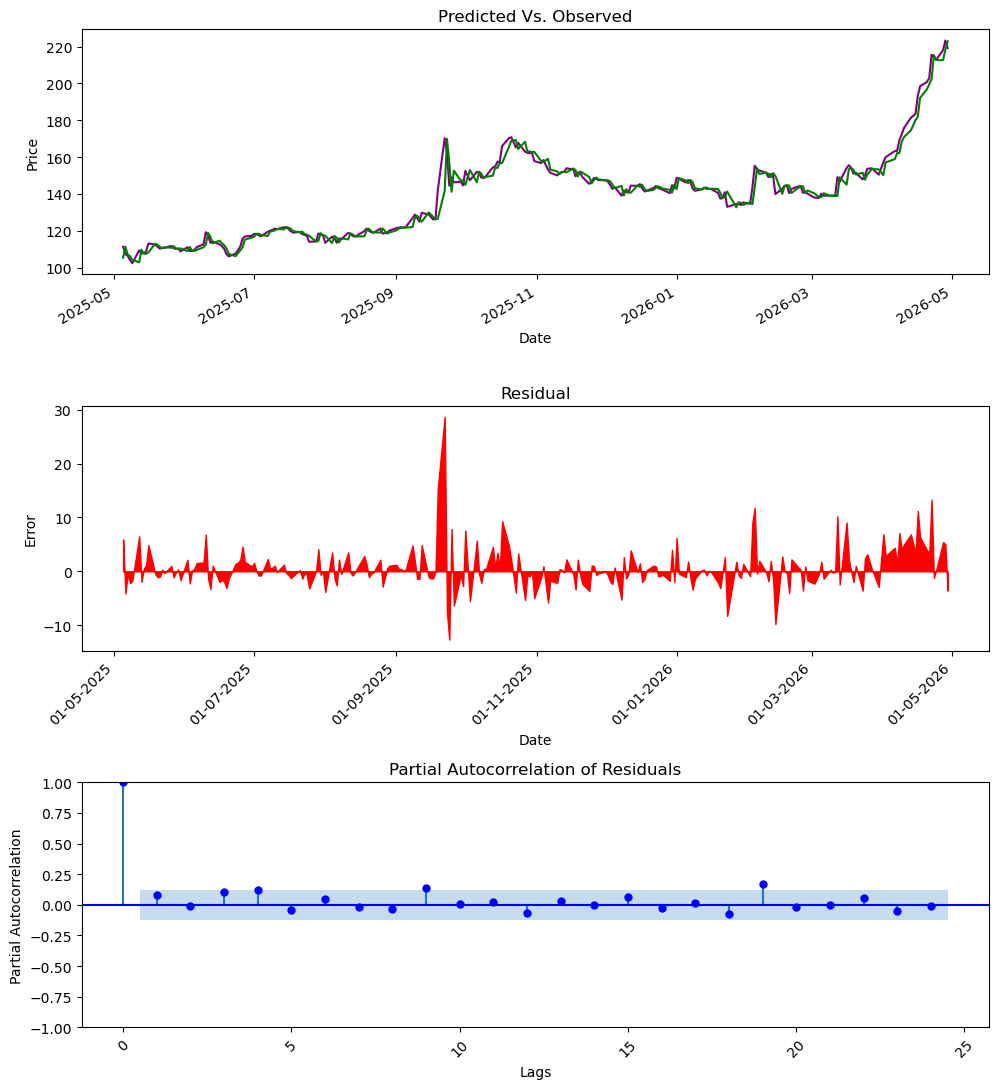

In [27]:
# Import libraries
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.dates as mdates


def model_performance(observed, predicted):

    
    """This function will print the Mean Absolute Error, Mean Squared Error,
    Root Mean Squared Error and Mean Absolute Percentage Error.
    This function will also display the residula plot and the ACF.
    """

    # Mean Absolute Error
    mae = mean_absolute_error(observed, predicted)
    print('The Mean Absolute Error is %.2f' % mae)

    # Mean Squared Error
    mse = mean_squared_error(observed, predicted)
    print('The Mean Squared Error is %.2f' % mse)

    # Root Mean Squared Error
    rmse = sqrt(mean_squared_error(observed, predicted))
    print('The Root Mean Squared Error is %.2f' % rmse)

    # Mean Absolute Percentage Error
    mape = 100 * ((observed-predicted)/observed).abs().mean()
    print('The Mean Absolute Percentage Error is %.2f' % mape)

    # Residuals
    residuals = observed - predicted
    labels = observed.index
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 11))
    
    # Plot residual
    observed.plot(ax=ax1, color='purple')
    predicted.plot(ax=ax1, color='green')
    ax1.set_ylabel('Price')
    ax1.set_title('Predicted Vs. Observed')
    
    # Plot residual
    ax2.fill_between(residuals.index, residuals.values, color='red')
    ax2.set_ylabel('Error')
    ax2.set_xlabel('Date')
    ax2.set_title('Residual')
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    ax2.xaxis.set_minor_formatter(mdates.DateFormatter("%d-%m-%Y"))
    _=plt.xticks(rotation=45)
    
    # Autocorrelation plot of residuals
    plot_pacf(residuals, ax=ax3, color='blue')
    ax3.set_xlabel('Lags')
    ax3.set_ylabel('Partial Autocorrelation')
    ax3.set_title('Partial Autocorrelation of Residuals')

    plt.tight_layout()
    plt.show()

# Call `model_performance` to evaluate the performance of the model
model_performance(data['Close'].iloc[rolling_window:],
                  data['predicted_price'].iloc[rolling_window:])

In [28]:
data.to_csv('C:/Users/gaura/Main_Project_EPAT/AdanipowerARIMA.csv')
print('\n File saved successfully') 


 File saved successfully


In [37]:
# Create signal
data['signal'] = np.where(data['predicted_price'].shift(1) <
                          data['predicted_price'], 1, 0)

data['returns'] = data['Close'].pct_change()

data['strategy_returns'] = data['signal'].shift(
    1) * data.iloc[rolling_window:].returns

In [38]:
sharpe_strategy = data['strategy_returns'].mean() / data['strategy_returns'].std() * np.sqrt(252) if data['strategy_returns'].std() != 0 else 0

In [39]:
print(sharpe_strategy)

1.1640971689018023


In [50]:
    sharpe_ratio = data['strategy_returns'].mean() / data['strategy_returns'].std() * np.sqrt(252)

    # Cumulative Returns
    cumulative_returns = (data['strategy_returns']+1).cumprod()
    
    # ---------- Drawdown calculations -------------------
    # Calculate the running maximum
    running_max = np.maximum.accumulate(cumulative_returns.dropna())
    # Ensure the value never drops below 1
    running_max[running_max < 1] = 1
    # Calculate the percentage drawdown
    drawdown = 100*((cumulative_returns)/running_max - 1)

    # Calculate the maximum drawdown
    max_dd = drawdown.min()

    # Print the statistics
    print('The Sharpe Ratio is %.2f' % sharpe_ratio)
    print("The maximum drawdown is %.2f" % max_dd + "%")

The Sharpe Ratio is 1.16
The maximum drawdown is -22.89%
